# 7-Ar. 실측전용 대체효과 모델 (2024-11+ 진짜 신재생, 순수 실측)

> 7-A(현행, 2022-24, 수요+계통신재생, R²0.784)는 **메인 예측 모델**로 유지.
> 본 모델은 **신재생 대체효과를 명시적으로 담는 설명용**. BTM/PPA 실측이 있는 2024-11+만 사용(역추정 없음).
> 피처: `true_demand`(=계량수요+BTM+PPA) + `true_renew`(=계통+BTM+PPA) + day_type + 달력.


In [1]:
import pandas as pd, numpy as np, sqlite3, lightgbm as lgb, json
import matplotlib.pyplot as plt, matplotlib as mpl
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mpl.rcParams['figure.dpi']=110; mpl.rcParams['axes.grid']=True; mpl.rcParams['font.size']=10
FIG=Path('fig'); FIG.mkdir(exist_ok=True); TAB=Path('tab'); TAB.mkdir(exist_ok=True)

rec=pd.read_parquet('../../1. data_fetcher_and_db/second_dataset/data/land_renew_reconstructed.parquet')
con=sqlite3.connect('../../1. data_fetcher_and_db/data/input_data_land.db')
cal=pd.read_sql('select timestamp,day_type from historical',con,parse_dates=['timestamp']); con.close()
d=rec.merge(cal,on='timestamp',how='left'); d['timestamp']=pd.to_datetime(d['timestamp'])
d=d[d.timestamp>='2024-11-01'].dropna(subset=['gen_gas_kr','true_demand','true_renew'])  # 실측 구간만
d['hour']=d.timestamp.dt.hour; d['dow']=d.timestamp.dt.dayofweek; d['month']=d.timestamp.dt.month; d['doy']=d.timestamp.dt.dayofyear
d['day_type']=d['day_type'].astype('category')
FEATS=['true_demand','true_renew','hour','dow','month','doy','day_type']; TARGET='gen_gas_kr'
tr=d[d.timestamp<'2025-10-01']; va=d[(d.timestamp>='2025-10-01')&(d.timestamp<'2026-01-01')]; te=d[d.timestamp>='2026-01-01']
print(f'train {len(tr)} (24-11~25-09) | val {len(va)} (25 Q4) | test {len(te)} (26 1~6월)')


train 7971 (24-11~25-09) | val 2195 (25 Q4) | test 3596 (26 1~6월)


## 1. 학습·평가 (test 2026 실측)

In [2]:
def metrics(y,p): return dict(MAE=mean_absolute_error(y,p),RMSE=mean_squared_error(y,p)**0.5,
        MAPE=np.mean(np.abs((y-p)/y))*100,R2=r2_score(y,p))
m=lgb.LGBMRegressor(objective='regression_l1',n_estimators=2000,learning_rate=0.03,num_leaves=31,
   min_child_samples=30,subsample=0.8,subsample_freq=1,colsample_bytree=0.8,random_state=42,n_jobs=-1,verbose=-1)
m.fit(tr[FEATS],tr[TARGET],eval_set=[(va[FEATS],va[TARGET])],eval_metric='l1',
      categorical_feature=['day_type'],callbacks=[lgb.early_stopping(100,verbose=False)])
pte=m.predict(te[FEATS]); mt=metrics(te[TARGET].values,pte)
print('test 2026:',{k:round(v,2) for k,v in mt.items()})
imp=pd.Series(m.feature_importances_,index=FEATS); imp=(imp/imp.sum()*100).round(1).sort_values(ascending=False)
print('중요도(%):',imp.to_dict())
imp.to_csv(TAB/'7ar_importance.csv')


test 2026: {'MAE': 2128.99, 'RMSE': 2726.0, 'MAPE': 12.03, 'R2': 0.8}
중요도(%): {'doy': 42.4, 'true_demand': 18.6, 'true_renew': 15.4, 'hour': 10.2, 'dow': 4.6, 'month': 4.4, 'day_type': 4.4}


## 2. 신재생 대체효과 (부분의존도) — 음의 기울기 확인

C:\Users\bjkim\AppData\Local\Temp\ipykernel_34088\3643112240.py:12: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'7ar_pdp.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_34088\3643112240.py:12: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'7ar_pdp.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_34088\3643112240.py:12: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'7ar_pdp.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_34088\3643112240.py:12: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'7ar_pdp.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_34088\3643112240.py:12: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing fr

C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_i

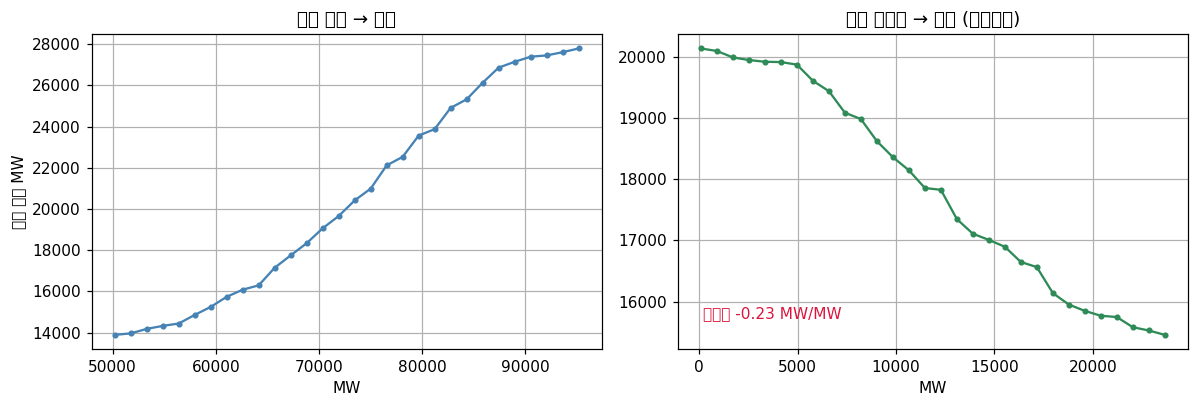

신재생 부분의존 기울기 = -0.233 MW/MW (음수 = 대체효과를 모델이 담음)


In [3]:
def pdp(feat,grid):
    base=tr[FEATS].sample(min(3000,len(tr)),random_state=0).copy(); out=[]
    for v in grid: b=base.copy(); b[feat]=v; out.append(m.predict(b).mean())
    return np.array(out)
gr=np.linspace(tr.true_renew.quantile(.02),tr.true_renew.quantile(.98),30)
gd=np.linspace(tr.true_demand.quantile(.02),tr.true_demand.quantile(.98),30)
pr=pdp('true_renew',gr); pdd=pdp('true_demand',gd)
fig,ax=plt.subplots(1,2,figsize=(11,3.8))
ax[0].plot(gd,pdd,'-o',ms=3,color='steelblue'); ax[0].set_title('진짜 수요 → 가스'); ax[0].set_xlabel('MW'); ax[0].set_ylabel('예측 가스 MW')
ax[1].plot(gr,pr,'-o',ms=3,color='seagreen'); ax[1].set_title('진짜 신재생 → 가스 (대체효과)'); ax[1].set_xlabel('MW')
sl=np.polyfit(gr,pr,1)[0]; ax[1].text(0.05,0.1,f'기울기 {sl:+.2f} MW/MW',transform=ax[1].transAxes,color='crimson')
plt.tight_layout(); plt.savefig(FIG/'7ar_pdp.png'); plt.show()
print(f'신재생 부분의존 기울기 = {sl:+.3f} MW/MW (음수 = 대체효과를 모델이 담음)')


## 3. 요약
- 실측전용(2024-11+) 모델: train ~8천행으로 충분. **test 2026 R²≈0.80, 신재생 중요도 ~15%**.
- 순수 실측(역추정 미사용) + 신재생 대체효과를 모델이 직접 담음 → 발표 설득력.
- 한계: 계절 이력 ~1년 → doy 의존도 높음(최신 레짐 데모엔 적합, 장기 일반화는 주의).
- 역할 분담: **7-A(현행, 긴 이력)=메인 예측 / 7-Ar(본 모델)=대체효과 설명 / 7-0b=전 기간 대체효과 EDA(역추정)**.


In [4]:
m.booster_.save_model('lgbm_land_gas_recent.txt')
json.dump({'features':FEATS,'window':'train 2024-11~2025-09 / val 2025Q4 / test 2026','measured_only':True,
           'metrics_test':{k:round(v,3) for k,v in mt.items()}},
          open('model_meta_recent.json','w',encoding='utf-8'),ensure_ascii=False,indent=2)
print('saved lgbm_land_gas_recent.txt, model_meta_recent.json')


saved lgbm_land_gas_recent.txt, model_meta_recent.json
